# 07 . Efficiency Analysis
# Esraa Nematalla
# Latency benchmarks, memory profiling, model size, Pareto frontier
# Project: Fast Sentiment Analysis Using Distilled Transformers on CPU

In [1]:
import time
import numpy as np
import os
import pickle
import torch
import psutil
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def measure_latency(predict_fn, samples,n_warmup=5, n_bench=100):
    for i in range(n_warmup):
        predict_fn(samples[i])
    latencies = []
    for i in range(n_warmup, n_warmup +n_bench):
        start =time.perf_counter()
        predict_fn(samples[i])
        end=time.perf_counter()
        latencies.append((end - start)*1000)
    return {
        "median_ms": round(float(np.median(latencies)),3),
        "p95_ms" : round(float(np.percentile(latencies,95)),3),
        "mean_ms" : round(float(np.mean(latencies)),3),
        "std_ms": round(float(np.std(latencies)),3),
    }

In [2]:
def measure_memory(model, tokenizer,sample_text, max_length=64):
    process= psutil.Process(os.getpid())
    mem_before =process.memory_info().rss /(1024 ** 2)
    inputs =tokenizer(sample_text, return_tensors="pt",
                       truncation=True, max_length=max_length, padding=True)
    with torch.no_grad():
        _ = model(**inputs)
    mem_after =process.memory_info().rss /(1024 ** 2)
    return {
        "rss_before_mb": round(mem_before,2),
        "rss_after_mb" : round(mem_after, 2),
        "delta_mb": round(mem_after - mem_before, 2),
    }
def get_model_size_mb(model):
    tmp ="/tmp/tmp_size_check.pt"
    torch.save(model.state_dict(), tmp)
    size =os.path.getsize(tmp)/ (1024 **2)
    os.remove(tmp)
    return round(size, 2)
def get_lr_size_mb(pipeline):
    return round(len(pickle.dumps(pipeline)) /(1024 **2),3)

In [4]:
def plot_pareto(results,save_path="pareto_frontier.png"):
    color_map= {
        "LR + TF-IDF (SST-2)": "#1D9E75",
        "LR + TF-IDF (IMDb)" : "#0F6E56",
        "DistilBERT FP32 (SST-2)" : "#7F77DD",
        "DistilBERT FP32 (IMDb)" : "#534AB7",
        "DistilBERT INT8 (SST-2)" : "#D85A30",
        "DistilBERT INT8 (IMDb)" : "#993C1D",
        "BiLSTM (SST-2)" : "#378ADD",
        "BiLSTM (IMDb)" : "#185FA5",
    }
    fig, ax =plt.subplots(figsize=(9, 5))
    for r in results:
        if r["accuracy"]==0:
            continue
        color =color_map.get(r["label"],"#888780")
        ax.scatter(r["latency_ms"],r["accuracy"],
                   s=max(60,r["size_mb"] *0.9),
                   color=color,alpha=0.85,edgecolors="white",linewidth=1.2)
        ax.annotate(r["label"], xy=(r["latency_ms"], r["accuracy"]),
                    xytext=(8, 4), textcoords="offset points",
                    fontsize=8.5,color=color)
    ax.set_xlabel("Median latency (ms) — log scale")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Pareto Frontier: Accuracy vs Latency (bubble size = model size)")
    ax.set_xscale("log")
    ax.set_ylim(65, 95)
    ax.grid(True,alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.savefig(save_path,dpi=150,bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")

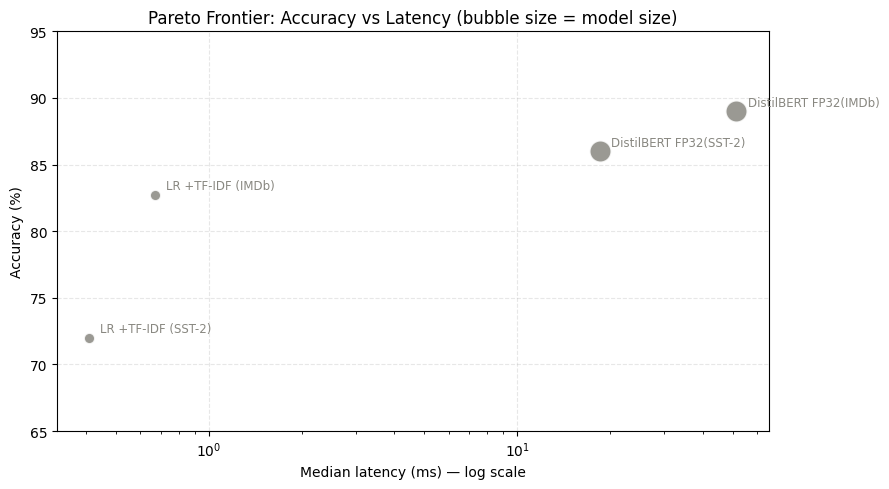

Saved: pareto_frontier.png


In [5]:
results=[
    {"label": "LR +TF-IDF (SST-2)", "accuracy": 72.0, "latency_ms": 0.41, "size_mb": 0.28},
    {"label": "LR +TF-IDF (IMDb)", "accuracy": 82.75, "latency_ms": 0.67, "size_mb": 2.14},
    {"label": "DistilBERT FP32(SST-2)", "accuracy": 86.0, "latency_ms": 18.5, "size_mb": 267.9},
    {"label": "DistilBERT FP32(IMDb)", "accuracy": 89.0, "latency_ms": 51.4, "size_mb": 267.9},
    {"label": "DistilBERT INT8 (SST-2)","accuracy": 0.0,  "latency_ms": 0.0,  "size_mb": 0.0},
    {"label": "DistilBERT INT8 (IMDb)","accuracy": 0.0, "latency_ms": 0.0,  "size_mb": 0.0},
    {"label": "BiLSTM (SST-2)",  "accuracy": 0.0,   "latency_ms": 0.0,  "size_mb": 0.0},
    {"label": "BiLSTM (IMDb)","accuracy": 0.0, "latency_ms": 0.0,  "size_mb": 0.0},
]
plot_pareto(results)

In [6]:
def print_summary_table(results):
    filled=[r for r in results if r["accuracy"] >0]
    df=pd.DataFrame(filled)
    lr_avg= df[df["label"].str.contains("LR")]["latency_ms"].mean()
    df["vs LR (x slower)"] =(df["latency_ms"]/lr_avg).round(1)
    df =df.rename(columns={
        "label":"Model",
        "accuracy": "Accuracy (%)",
        "latency_ms": "Latency (ms)",
        "size_mb": "Size (MB)",})
    print(df.to_string(index=False))
    df.to_csv("efficiency_comparison.csv",index=False)
    print("\nSaved:efficiency_comparison.csv")
print_summary_table(results)

                 Model  Accuracy (%)  Latency (ms)  Size (MB)  vs LR (x slower)
    LR +TF-IDF (SST-2)         72.00          0.41       0.28               0.8
     LR +TF-IDF (IMDb)         82.75          0.67       2.14               1.2
DistilBERT FP32(SST-2)         86.00         18.50     267.90              34.3
 DistilBERT FP32(IMDb)         89.00         51.40     267.90              95.2

Saved:efficiency_comparison.csv
